In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv')

print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

✅ Dataset chargé : 4372 lignes, 52 colonnes


In [3]:
# NewsletterSubscribed = toujours "Yes" → aucune information utile
# LastLoginIP = adresse IP brute → pas utilisable directement
# CustomerID = juste un identifiant → pas une feature ML

cols_to_drop = ['NewsletterSubscribed', 'LastLoginIP', 'CustomerID']

# On vérifie d'abord lesquelles existent vraiment
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df = df.drop(columns=cols_to_drop)

print(f"✅ Colonnes supprimées : {cols_to_drop}")
print(f"👉 Nouvelles dimensions : {df.shape}")

✅ Colonnes supprimées : ['NewsletterSubscribed', 'LastLoginIP']
👉 Nouvelles dimensions : (4372, 50)


In [4]:
print(df.columns.tolist())


[' CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Churn']


In [5]:
# Afficher les valeurs uniques de ces colonnes
print("SupportTicketsCount valeurs spéciales:")
print(df['SupportTicketsCount'].value_counts().sort_index())

print("\nSatisfactionScore valeurs spéciales:")
print(df['SatisfactionScore'].value_counts().sort_index())

SupportTicketsCount valeurs spéciales:
SupportTicketsCount
-1.0        43
 0.0       596
 1.0      1140
 2.0      1183
 3.0       753
 4.0       365
 5.0       141
 6.0        41
 7.0        17
 8.0         3
 9.0         3
 999.0      87
Name: count, dtype: int64

SatisfactionScore valeurs spéciales:
SatisfactionScore
-1.0     115
 0.0     120
 1.0     824
 2.0     777
 3.0     789
 4.0     786
 5.0     847
 99.0    114
Name: count, dtype: int64


In [6]:
# Remplacer les valeurs aberrantes par NaN (= manquant)
# SupportTicketsCount : -1 et 999 sont aberrants
df['SupportTicketsCount'] = df['SupportTicketsCount'].replace([-1, 999], np.nan)

# SatisfactionScore : -1 et 99 sont aberrants, 0 aussi (pas de note)
df['SatisfactionScore'] = df['SatisfactionScore'].replace([-1, 0, 99], np.nan)

print("✅ Valeurs aberrantes remplacées par NaN")
print(f"\nNaN dans SupportTicketsCount : {df['SupportTicketsCount'].isna().sum()}")
print(f"NaN dans SatisfactionScore  : {df['SatisfactionScore'].isna().sum()}")

✅ Valeurs aberrantes remplacées par NaN

NaN dans SupportTicketsCount : 130
NaN dans SatisfactionScore  : 349


In [7]:
from sklearn.impute import SimpleImputer

# Colonnes numériques avec des NaN
cols_to_impute = ['Age', 'AvgDaysBetweenPurchases', 
                  'SupportTicketsCount', 'SatisfactionScore']

# Imputation par la médiane (robuste aux valeurs extrêmes)
imputer = SimpleImputer(strategy='median')
df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

print("✅ Valeurs manquantes imputées par la médiane")
print("\nVérification — NaN restants :")
print(df[cols_to_impute].isna().sum())

✅ Valeurs manquantes imputées par la médiane

Vérification — NaN restants :
Age                        0
AvgDaysBetweenPurchases    0
SupportTicketsCount        0
SatisfactionScore          0
dtype: int64


In [8]:
# Convertir en format date
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], 
                                         dayfirst=True, 
                                         errors='coerce')

# Extraire des features utiles
df['RegYear']    = df['RegistrationDate'].dt.year
df['RegMonth']   = df['RegistrationDate'].dt.month
df['RegDay']     = df['RegistrationDate'].dt.day
df['RegWeekday'] = df['RegistrationDate'].dt.weekday

# Supprimer la colonne originale (plus besoin)
df = df.drop(columns=['RegistrationDate'])

print("✅ RegistrationDate convertie et décomposée !")
print(f"👉 Nouvelles colonnes : RegYear, RegMonth, RegDay, RegWeekday")
print(f"👉 Dimensions actuelles : {df.shape}")

✅ RegistrationDate convertie et décomposée !
👉 Nouvelles colonnes : RegYear, RegMonth, RegDay, RegWeekday
👉 Dimensions actuelles : (4372, 53)


C:\Users\rabdelmoula\AppData\Local\Temp\ipykernel_19280\2976387950.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'],


In [9]:
# Plus aucune valeur manquante ?
total_nan = df.isnull().sum().sum()
print(f"Total valeurs manquantes restantes : {total_nan}")
print(f"\nDimensions finales : {df.shape}")
print(f"\nTypes de colonnes :")
print(df.dtypes.value_counts())

Total valeurs manquantes restantes : 0

Dimensions finales : (4372, 53)

Types de colonnes :
int64      20
str        15
float64    14
int32       4
Name: count, dtype: int64


In [10]:
# Identifier les colonnes texte
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Colonnes catégorielles ({len(cat_cols)}) :")
for col in cat_cols:
    print(f"  - {col} : {df[col].unique()[:5]}")

Colonnes catégorielles (15) :
  - RFMSegment : <StringArray>
['Fidèles', 'Champions', 'Potentiels', 'Dormants']
Length: 4, dtype: str
  - AgeCategory : <StringArray>
['Inconnu', '45-54', '25-34', '65+', '35-44']
Length: 5, dtype: str
  - SpendingCategory : <StringArray>
['VIP', 'High', 'Medium', 'Low']
Length: 4, dtype: str
  - CustomerType : <StringArray>
['Perdu', 'Régulier', 'Hyperactif', 'Nouveau', 'Occasionnel']
Length: 5, dtype: str
  - FavoriteSeason : <StringArray>
['Hiver', 'Automne', 'Été', 'Printemps']
Length: 4, dtype: str
  - PreferredTimeOfDay : <StringArray>
['Matin', 'Midi', 'Après-midi', 'Soir']
Length: 4, dtype: str
  - Region : <StringArray>
['UK', 'Europe continentale', 'Océanie', 'Europe du Nord', 'Autre']
Length: 5, dtype: str
  - LoyaltyLevel : <StringArray>
['Jeune', 'Établi', 'Ancien', 'Nouveau']
Length: 4, dtype: str
  - ChurnRiskCategory : <StringArray>
['Critique', 'Moyen', 'Faible', 'Élevé']
Length: 4, dtype: str
  - WeekendPreference : <StringArray>
['Inco

C:\Users\rabdelmoula\AppData\Local\Temp\ipykernel_19280\3407505880.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Colonnes ordinales (ont un ordre logique)
ordinal_cols = ['RFMSegment', 'AgeCategory', 'SpendingCategory', 
                'LoyaltyLevel', 'ChurnRiskCategory', 'BasketSizeCategory',
                'PreferredTimeOfDay', 'WeekendPreference', 'ProductDiversity']

# Colonnes nominales (pas d'ordre) → One-Hot Encoding
nominal_cols = ['CustomerType', 'FavoriteSeason', 'Region', 
                'Gender', 'AccountStatus']

# 1. Label Encoding pour les ordinales
for col in ordinal_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"✅ {col} encodée")

# 2. One-Hot Encoding pour les nominales
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"\n✅ Encoding terminé !")
print(f"👉 Nouvelles dimensions : {df.shape}")

✅ RFMSegment encodée
✅ AgeCategory encodée
✅ SpendingCategory encodée
✅ LoyaltyLevel encodée
✅ ChurnRiskCategory encodée
✅ BasketSizeCategory encodée
✅ PreferredTimeOfDay encodée
✅ WeekendPreference encodée
✅ ProductDiversity encodée

✅ Encoding terminé !
👉 Nouvelles dimensions : (4372, 72)


In [12]:
# Voir toutes les colonnes après encoding
print(f"Total colonnes : {df.shape[1]}")
print("\nListe de toutes les colonnes :")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

Total colonnes : 72

Liste de toutes les colonnes :
  1.  CustomerID
  2. Recency
  3. Frequency
  4. MonetaryTotal
  5. MonetaryAvg
  6. MonetaryStd
  7. MonetaryMin
  8. MonetaryMax
  9. TotalQuantity
  10. AvgQuantityPerTransaction
  11. MinQuantity
  12. MaxQuantity
  13. CustomerTenureDays
  14. FirstPurchaseDaysAgo
  15. PreferredDayOfWeek
  16. PreferredHour
  17. PreferredMonth
  18. WeekendPurchaseRatio
  19. AvgDaysBetweenPurchases
  20. UniqueProducts
  21. UniqueDescriptions
  22. AvgProductsPerTransaction
  23. UniqueCountries
  24. NegativeQuantityCount
  25. ZeroPriceCount
  26. CancelledTransactions
  27. ReturnRatio
  28. TotalTransactions
  29. UniqueInvoices
  30. AvgLinesPerInvoice
  31. Age
  32. SupportTicketsCount
  33. SatisfactionScore
  34. RFMSegment
  35. AgeCategory
  36. SpendingCategory
  37. PreferredTimeOfDay
  38. LoyaltyLevel
  39. ChurnRiskCategory
  40. WeekendPreference
  41. BasketSizeCategory
  42. ProductDiversity
  43. Country
  44. Churn
  45.

In [13]:
# Afficher les 5 premières lignes
df.head()

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region_Europe du Nord,Region_Europe du Sud,Region_Moyen-Orient,Region_Océanie,Region_UK,Gender_M,Gender_Unknown,AccountStatus_Closed,AccountStatus_Pending,AccountStatus_Suspended
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,False,False,False,False,True,False,True,False,False,False
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,False,False,False,False,True,True,False,False,False,False
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,False,False,False,False,False,False,True,False,False,False
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,False,False,False,False,True,False,True,False,False,False
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,False,False,False,False,True,True,False,False,False,False


In [14]:
# Filtrer uniquement les colonnes créées par One-Hot Encoding
onehot_cols = [col for col in df.columns if '_' in col and 
               any(nom in col for nom in ['CustomerType', 'FavoriteSeason', 
                                           'Region', 'Gender', 'AccountStatus'])]

print(f"Colonnes One-Hot créées ({len(onehot_cols)}) :")
print(df[onehot_cols].head(10))

Colonnes One-Hot créées (24) :
   CustomerType_Nouveau  CustomerType_Occasionnel  CustomerType_Perdu  \
0                 False                     False                True   
1                 False                     False               False   
2                 False                     False               False   
3                  True                     False               False   
4                 False                     False                True   
5                 False                     False               False   
6                 False                     False               False   
7                 False                     False               False   
8                 False                     False               False   
9                 False                     False               False   

   CustomerType_Régulier  FavoriteSeason_Hiver  FavoriteSeason_Printemps  \
0                  False                  True                     False   
1            

In [15]:
# Country a trop de valeurs uniques → Target Encoding
# On remplace chaque pays par le taux de churn moyen de ce pays
country_churn = df.groupby('Country')['Churn'].mean()
df['Country'] = df['Country'].map(country_churn)

print("✅ Country encodée par taux de churn moyen")
print(df['Country'].describe())

✅ Country encodée par taux de churn moyen
count    4372.000000
mean        0.332571
std         0.053312
min         0.000000
25%         0.332405
50%         0.332405
75%         0.332405
max         1.000000
Name: Country, dtype: float64


In [16]:
print(f"Dimensions actuelles : {df.shape}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"\nTypes de colonnes :")
print(df.dtypes.value_counts())

Dimensions actuelles : (4372, 72)
Valeurs manquantes : 0

Types de colonnes :
int64      29
bool       24
float64    15
int32       4
Name: count, dtype: int64


In [23]:
# Recharger les données brutes pour récupérer LastLoginIP
df_raw = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv')

# Extraire des features depuis LastLoginIP
def parse_ip(ip):
    try:
        parts = ip.strip().split('.')
        first = int(parts[0])
        # IP privée : 10.x.x.x, 172.16-31.x.x, 192.168.x.x
        is_private = (
            first == 10 or
            first == 192 and int(parts[1]) == 168 or
            first == 172 and 16 <= int(parts[1]) <= 31
        )
        return pd.Series([int(parts[0]), int(is_private)])
    except:
        return pd.Series([0, -1])

df_raw[['IP_FirstOctet', 'IP_IsPrivate']] = df_raw['LastLoginIP'].apply(parse_ip)

print("✅ LastLoginIP parsée !")
print(df_raw[['LastLoginIP', 'IP_FirstOctet', 'IP_IsPrivate']].head(10))
print(f"\nIPs privées : {(df_raw['IP_IsPrivate']==1).sum()}")
print(f"IPs publiques : {(df_raw['IP_IsPrivate']==0).sum()}")

✅ LastLoginIP parsée !
       LastLoginIP  IP_FirstOctet  IP_IsPrivate
0   59.252.219.201             59             0
1    77.255.247.14             77             0
2     51.139.78.80             51             0
3    10.212.80.124             10             1
4    186.34.121.80            186             0
5    206.53.156.18            206             0
6  154.102.135.173            154             0
7    98.239.241.45             98             0
8   199.225.35.180            199             0
9   114.231.21.241            114             0

IPs privées : 21
IPs publiques : 4351


In [18]:
# X = toutes les features (ce qu'on donne au modèle)
# y = la target (ce qu'on veut prédire)
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"✅ Séparation X / y")
print(f"👉 X (features) : {X.shape}")
print(f"👉 y (target)   : {y.shape}")
print(f"\nRépartition du Churn :")
print(y.value_counts())

✅ Séparation X / y
👉 X (features) : (4372, 71)
👉 y (target)   : (4372,)

Répartition du Churn :
Churn
0    2918
1    1454
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

# Identifier les colonnes numériques (pas les booléennes)
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
print(f"Colonnes à normaliser : {len(num_cols)}")

# Normalisation
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("✅ Normalisation terminée !")
print(f"\nVérification (moyenne ≈ 0, std ≈ 1) :")
print(X[num_cols].describe().loc[['mean', 'std']].round(2))

Colonnes à normaliser : 47
✅ Normalisation terminée !

Vérification (moyenne ≈ 0, std ≈ 1) :
       CustomerID  Recency  Frequency  MonetaryTotal  MonetaryAvg  \
mean         -0.0     -0.0        0.0            0.0         -0.0   
std           1.0      1.0        1.0            1.0          1.0   

      MonetaryStd  MonetaryMin  MonetaryMax  TotalQuantity  \
mean         -0.0          0.0          0.0            0.0   
std           1.0          1.0          1.0            1.0   

      AvgQuantityPerTransaction  ...  LoyaltyLevel  ChurnRiskCategory  \
mean                       -0.0  ...          -0.0               -0.0   
std                         1.0  ...           1.0                1.0   

      WeekendPreference  BasketSizeCategory  ProductDiversity  Country  \
mean                0.0                -0.0               0.0     -0.0   
std                 1.0                 1.0               1.0      1.0   

      RegYear  RegMonth  RegDay  RegWeekday  
mean      0.0       0.0

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% pour le test
    random_state=42,      # Pour reproduire les mêmes résultats
    stratify=y            # Garder la même proportion de churn
)

print(f"✅ Split Train/Test effectué !")
print(f"\n👉 X_train : {X_train.shape}")
print(f"👉 X_test  : {X_test.shape}")
print(f"\nRépartition Churn dans train :")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nRépartition Churn dans test :")
print(y_test.value_counts(normalize=True).round(3))

✅ Split Train/Test effectué !

👉 X_train : (3497, 71)
👉 X_test  : (875, 71)

Répartition Churn dans train :
Churn
0    0.667
1    0.333
Name: proportion, dtype: float64

Répartition Churn dans test :
Churn
0    0.667
1    0.333
Name: proportion, dtype: float64


In [21]:
import os

# Créer les dossiers
os.makedirs(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed', exist_ok=True)
os.makedirs(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test', exist_ok=True)

# Sauvegarder les données processed
X.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\X_processed.csv', index=False)
y.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\y_processed.csv', index=False)

# Sauvegarder train/test
X_train.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\X_train.csv', index=False)
X_test.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\X_test.csv', index=False)
y_train.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\y_train.csv', index=False)
y_test.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\y_test.csv', index=False)

print("✅ Toutes les données sauvegardées !")
print(f"\n📁 data/processed/")
print(f"   - X_processed.csv")
print(f"   - y_processed.csv")
print(f"\n📁 data/train_test/")
print(f"   - X_train.csv : {X_train.shape}")
print(f"   - X_test.csv  : {X_test.shape}")
print(f"   - y_train.csv : {y_train.shape}")
print(f"   - y_test.csv  : {y_test.shape}")

✅ Toutes les données sauvegardées !

📁 data/processed/
   - X_processed.csv
   - y_processed.csv

📁 data/train_test/
   - X_train.csv : (3497, 71)
   - X_test.csv  : (875, 71)
   - y_train.csv : (3497,)
   - y_test.csv  : (875,)


In [24]:
# Charger les données processed
X = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\X_processed.csv')
y = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\y_processed.csv')

# Créer nouvelles features
X['MonetaryPerDay']  = X['MonetaryTotal'] / (X['Recency'] + 1)
X['AvgBasketValue']  = X['MonetaryTotal'] / (X['Frequency'] + 1)
X['TenureRatio']     = X['Recency'] / (X['CustomerTenureDays'] + 1)

# Ajouter les features IP
X['IP_FirstOctet'] = df_raw['IP_FirstOctet'].values[:len(X)]
X['IP_IsPrivate']  = df_raw['IP_IsPrivate'].values[:len(X)]

print("✅ Feature Engineering terminé !")
print(f"👉 Nouvelles dimensions : {X.shape}")
print(f"\nNouvelles features créées :")
print(X[['MonetaryPerDay', 'AvgBasketValue', 'TenureRatio', 
          'IP_FirstOctet', 'IP_IsPrivate']].describe().round(2))

✅ Feature Engineering terminé !
👉 Nouvelles dimensions : (4372, 76)

Nouvelles features créées :
       MonetaryPerDay  AvgBasketValue  TenureRatio  IP_FirstOctet  \
count         4372.00         4372.00      4372.00        4372.00   
mean             0.60           -0.14       -47.64         128.13   
std              8.56            0.27       174.21          74.71   
min             -2.39           -1.34      -669.05           1.00   
25%             -0.32           -0.32        -1.61          62.75   
50%             -0.12           -0.20        -0.32         127.00   
75%             -0.05           -0.03         0.34         194.00   
max            321.48            4.57       664.37         255.00   

       IP_IsPrivate  
count       4372.00  
mean           0.00  
std            0.07  
min            0.00  
25%            0.00  
50%            0.00  
75%            0.00  
max            1.00  


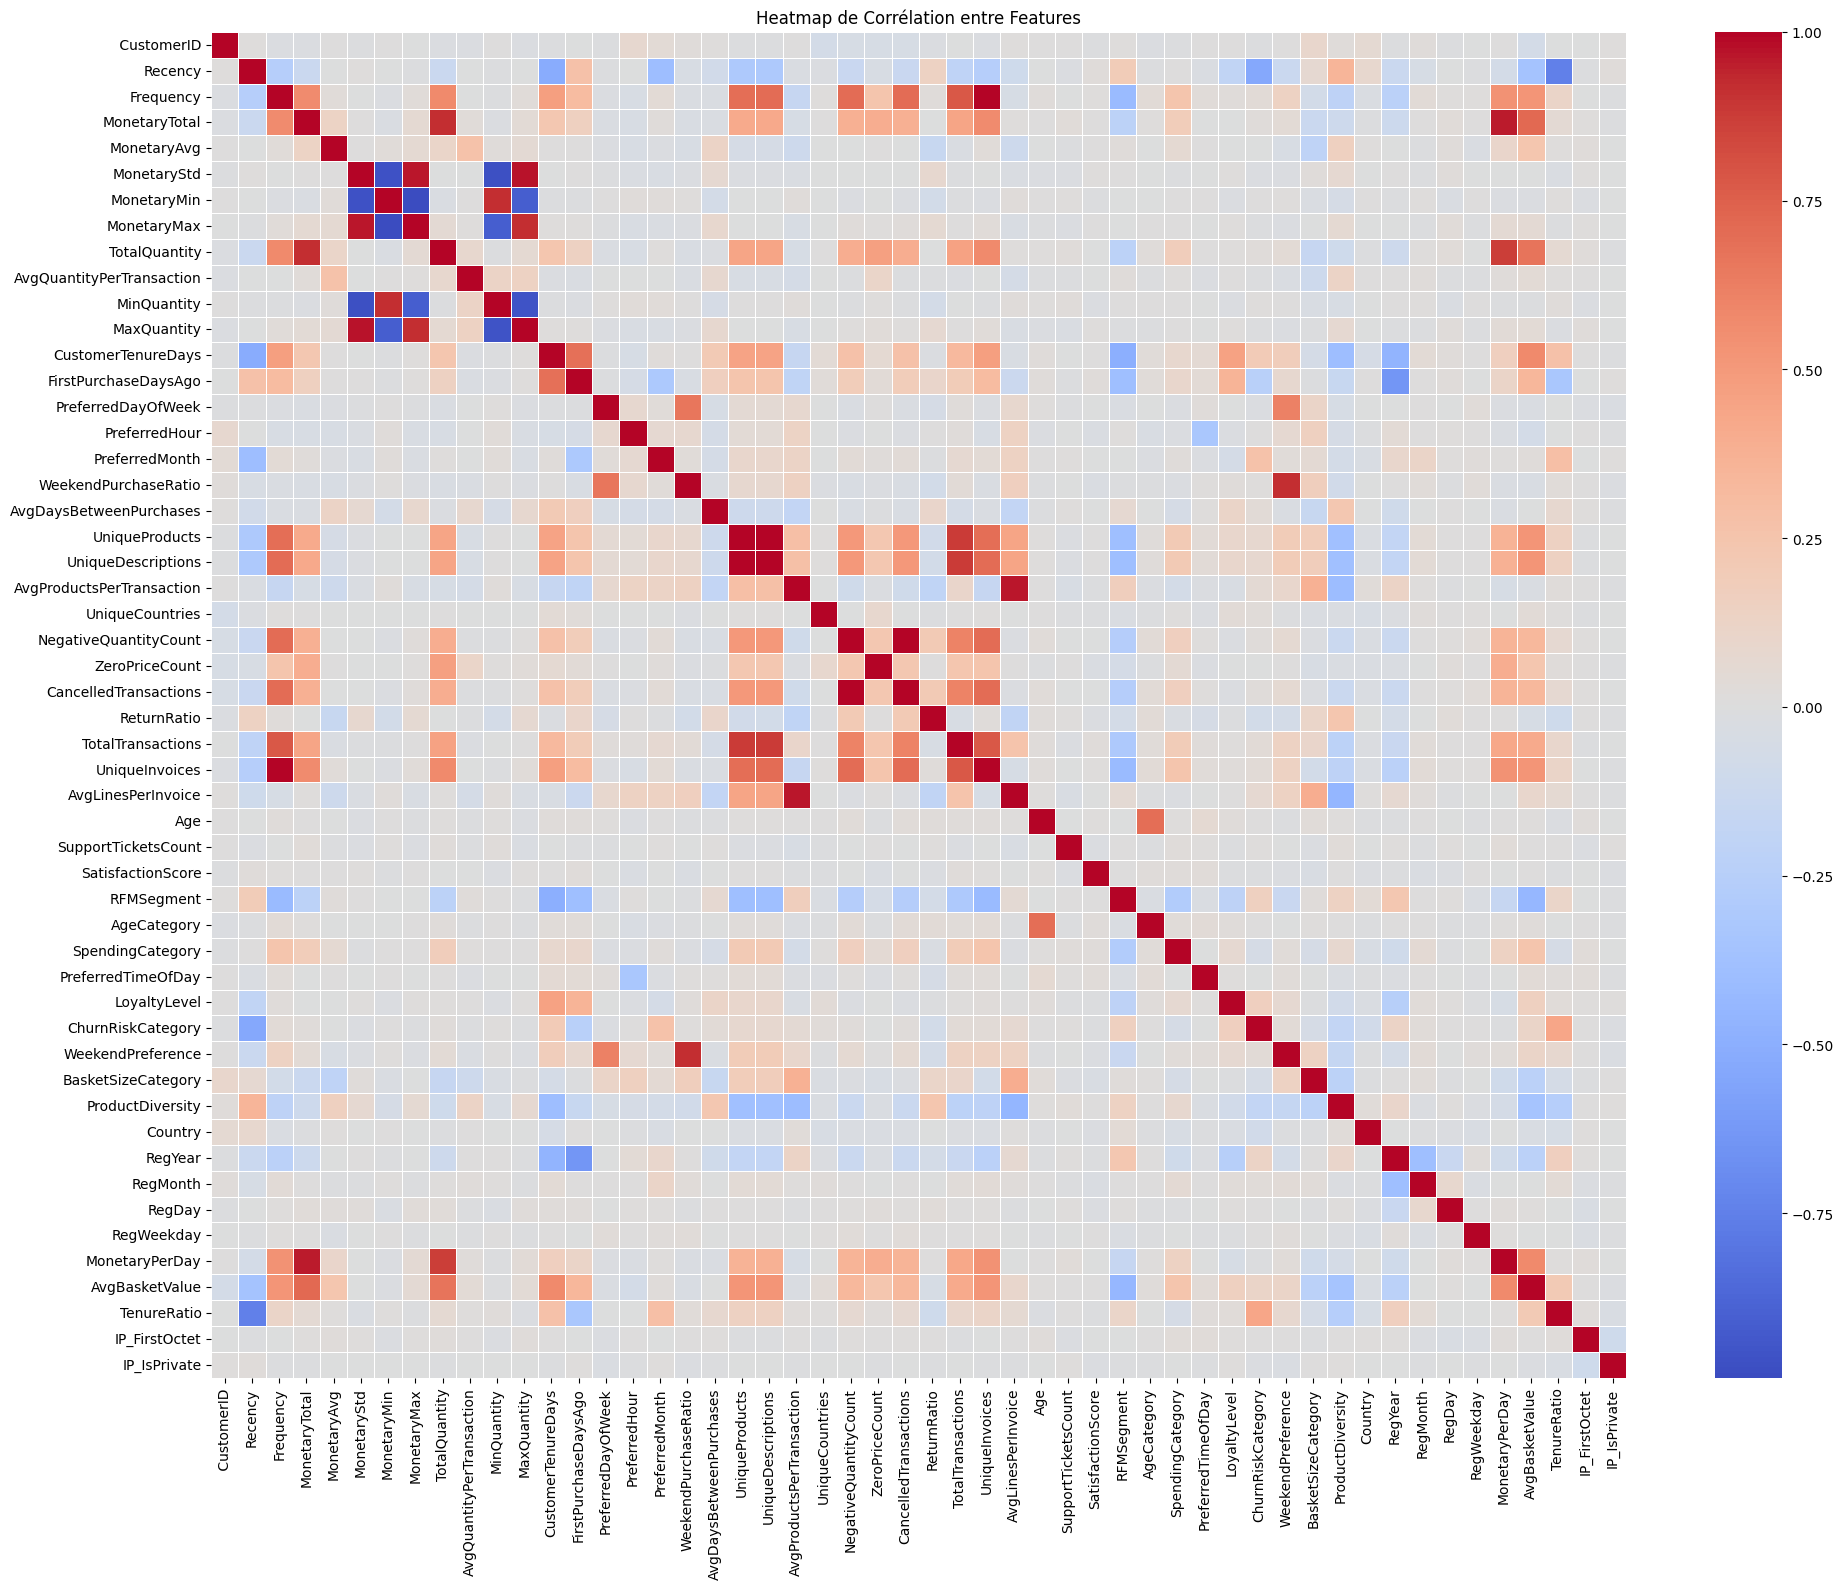

Dimensions de la matrice : (52, 52)


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 16))

# Calculer la corrélation sur les colonnes numériques
corr_matrix = X.select_dtypes(include=['float64', 'int64', 'int32']).corr()

# Afficher la heatmap
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot=False)

plt.title('Heatmap de Corrélation entre Features')
plt.tight_layout()
plt.show()

print(f"Dimensions de la matrice : {corr_matrix.shape}")

In [26]:
# Trouver les paires avec corrélation > 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Corrélation': round(corr_matrix.iloc[i, j], 2)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Corrélation', 
                                                           ascending=False)
print(f"Paires très corrélées (|corr| > 0.8) : {len(high_corr_pairs)}")
print(high_corr_df.to_string())

Paires très corrélées (|corr| > 0.8) : 20
                    Feature 1              Feature 2  Corrélation
0                   Frequency         UniqueInvoices         1.00
19      NegativeQuantityCount  CancelledTransactions         1.00
15             UniqueProducts     UniqueDescriptions         1.00
4                 MonetaryStd            MonetaryMax         0.97
6                 MonetaryStd            MaxQuantity         0.97
18  AvgProductsPerTransaction     AvgLinesPerInvoice         0.96
2               MonetaryTotal         MonetaryPerDay         0.96
1               MonetaryTotal          TotalQuantity         0.92
11                MonetaryMax            MaxQuantity         0.92
14       WeekendPurchaseRatio      WeekendPreference         0.92
8                 MonetaryMin            MinQuantity         0.92
17         UniqueDescriptions      TotalTransactions         0.88
16             UniqueProducts      TotalTransactions         0.88
12              TotalQuantity     

In [27]:
# Features à supprimer (redondantes)
cols_to_remove = [
    'UniqueInvoices',          # = Frequency
    'UniqueDescriptions',      # = UniqueProducts  
    'CancelledTransactions',   # = NegativeQuantityCount
    'MonetaryMax',             # redondant avec MonetaryStd
    'MonetaryMin',             # redondant avec MonetaryStd
    'MinQuantity',             # redondant avec MaxQuantity
    'WeekendPreference',       # = WeekendPurchaseRatio
    'MonetaryPerDay',          # calculé depuis MonetaryTotal
    'TotalTransactions',       # redondant avec UniqueProducts
]

# Supprimer uniquement celles qui existent
cols_to_remove = [c for c in cols_to_remove if c in X.columns]
X = X.drop(columns=cols_to_remove)

print(f"✅ Features redondantes supprimées : {len(cols_to_remove)}")
print(f"👉 Nouvelles dimensions : {X.shape}")

✅ Features redondantes supprimées : 9
👉 Nouvelles dimensions : (4372, 67)


In [28]:
X.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\X_processed.csv', index=False)
y.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\y_processed.csv', index=False)

print("✅ Données sauvegardées !")
print(f"👉 X final : {X.shape}")

✅ Données sauvegardées !
👉 X final : (4372, 67)


In [29]:
from sklearn.model_selection import train_test_split

# Reséparer avec les données finales (67 colonnes)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y.squeeze(),
    test_size=0.2,
    random_state=42,
    stratify=y.squeeze()
)

# Sauvegarder les nouveaux fichiers
X_train_new.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\X_train.csv', index=False)
X_test_new.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\X_test.csv', index=False)
y_train_new.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\y_train.csv', index=False)
y_test_new.to_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\y_test.csv', index=False)

print("✅ Fichiers train/test mis à jour !")
print(f"X_train : {X_train_new.shape}")
print(f"X_test  : {X_test_new.shape}")

✅ Fichiers train/test mis à jour !
X_train : (3497, 67)
X_test  : (875, 67)
